# Lecture A04: Categories and Causes

Companion notebook for [[Lecture A04 - Categories and Causes]]. Prerequisites: [[A01|A01]], [[A02|A02]], [[A03|A03]].

**Part 1** — Lecture walkthrough: posterior predictions with epistemic/aleatoric uncertainty, generative model with sex, three estimands from one DAG, index vs dummy variables, fitting categorical models, computing causal contrasts

**Part 2** — Applied exercises with Slovenian data: property type as index variable, forensic device contrasts, total vs direct effect of location on price, municipality categories, authenticity category contrasts

**Convention:** 89% credible intervals (McElreath default).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, optimize
from pathlib import Path

SEED = 42
rng = np.random.default_rng(SEED)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.dpi": 150,
    "figure.dpi": 150,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
})

C_PRIOR = "#9ca3af"
C_POSTERIOR = "#2563eb"
C_LIKELIHOOD = "#dc2626"
C_DATA = "#059669"
C_ACCENT = "#d97706"
C_POINT = "#111827"
C_FEMALE = "#dc2626"
C_MALE = "#2563eb"

DATA_DIR = Path("../data")
CI_LEVEL = 0.89
N_SAMPLES = 10_000

---

# Part 1: Lecture Walkthrough

## 1. Posterior Predictions: Epistemic vs Aleatoric Uncertainty

Completing the A03 workflow. Two types of uncertainty in regression predictions:

- **Epistemic** (narrow band): uncertainty about the regression line. Shrinks with more data.
- **Aleatoric** (wide band): irreducible scatter around the line from unobserved causes. Does not shrink with more data.

OTP Bank cares about the narrow band (collateral benchmarks). A buyer needs the wide band (specific transaction risk).

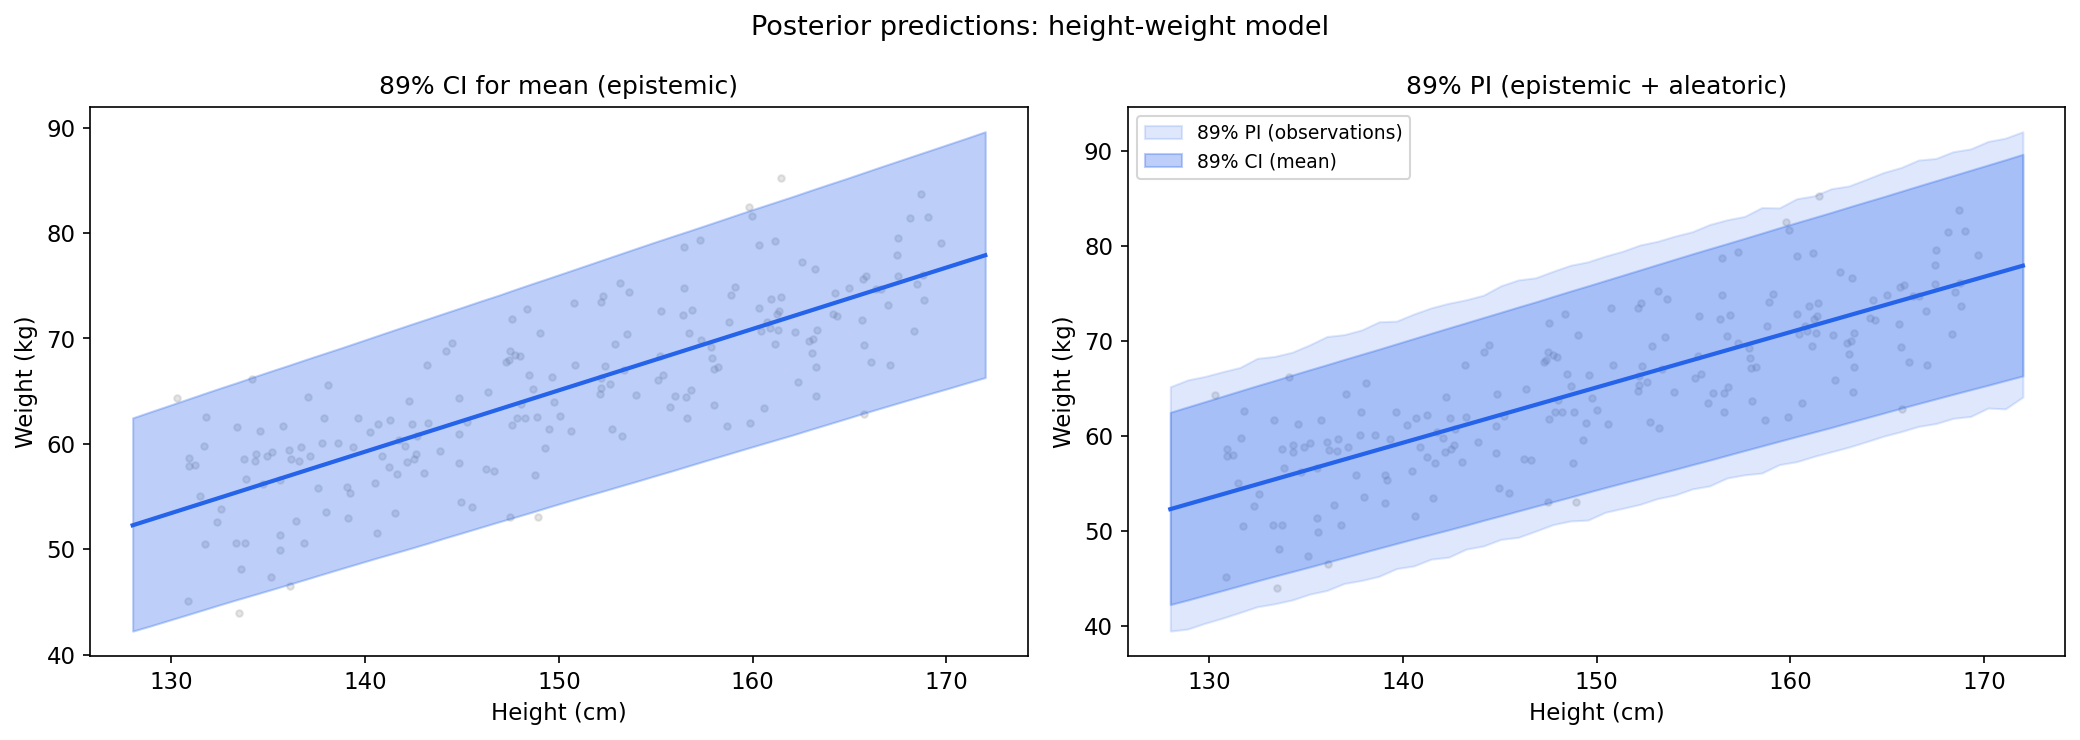

In [2]:
# Simulated height-weight data (continuing from A03)
rng_sim = np.random.default_rng(SEED)
n_sim = 200
h_sim = rng_sim.uniform(130, 170, size=n_sim)
w_sim = -10 + 0.5 * h_sim + rng_sim.normal(0, 5, size=n_sim)

# Posterior sampling via OLS + residual bootstrap (analytical posterior for Gaussian linear model)
def posterior_samples_ols(heights, weights, n_samples=N_SAMPLES, seed=SEED):
    """Generate posterior samples for linear regression parameters."""
    rng = np.random.default_rng(seed)
    coeffs = np.polyfit(heights, weights, 1)
    beta_hat, alpha_hat = coeffs
    resid = weights - (alpha_hat + beta_hat * heights)
    sigma_hat = np.std(resid, ddof=2)
    n = len(heights)
    ss_h = np.sum((heights - heights.mean()) ** 2)

    alphas, betas, sigmas = [], [], []
    for _ in range(n_samples):
        s2 = sigma_hat**2 * (n - 2) / rng.chisquare(n - 2)
        s = np.sqrt(s2)
        b = rng.normal(beta_hat, s / np.sqrt(ss_h))
        a = rng.normal(alpha_hat, s * np.sqrt(1/n + heights.mean()**2 / ss_h))
        alphas.append(a); betas.append(b); sigmas.append(s)
    return np.array(alphas), np.array(betas), np.array(sigmas)

a_post, b_post, s_post = posterior_samples_ols(h_sim, w_sim)

h_seq = np.linspace(128, 172, 50)
mu_all = a_post[:, None] + b_post[:, None] * h_seq[None, :]
w_pred = mu_all + rng_sim.normal(0, s_post[:, None], size=mu_all.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Epistemic uncertainty
axes[0].scatter(h_sim, w_sim, alpha=0.2, s=10, color="gray")
axes[0].plot(h_seq, mu_all.mean(axis=0), color=C_POSTERIOR, linewidth=2)
axes[0].fill_between(h_seq, np.percentile(mu_all, 5.5, axis=0),
                     np.percentile(mu_all, 94.5, axis=0), alpha=0.3, color=C_POSTERIOR)
axes[0].set_title("89% CI for mean (epistemic)")
axes[0].set_xlabel("Height (cm)"); axes[0].set_ylabel("Weight (kg)")

# Epistemic + aleatoric
axes[1].scatter(h_sim, w_sim, alpha=0.2, s=10, color="gray")
axes[1].plot(h_seq, mu_all.mean(axis=0), color=C_POSTERIOR, linewidth=2)
axes[1].fill_between(h_seq, np.percentile(w_pred, 5.5, axis=0),
                     np.percentile(w_pred, 94.5, axis=0), alpha=0.15, color=C_POSTERIOR,
                     label="89% PI (observations)")
axes[1].fill_between(h_seq, np.percentile(mu_all, 5.5, axis=0),
                     np.percentile(mu_all, 94.5, axis=0), alpha=0.3, color=C_POSTERIOR,
                     label="89% CI (mean)")
axes[1].set_title("89% PI (epistemic + aleatoric)")
axes[1].set_xlabel("Height (cm)"); axes[1].set_ylabel("Weight (kg)")
axes[1].legend(fontsize=9)

plt.suptitle("Posterior predictions: height-weight model", fontsize=13)
plt.tight_layout()
plt.show()

## 2. Generative Model with a Categorical Variable

Extend the DAG to include sex:

$S \rightarrow H$, $S \rightarrow W$, $H \rightarrow W$

Sex influences both height (directly) and weight (directly + indirectly through height). Unobserved causes $U, V, Y$ produce scatter.

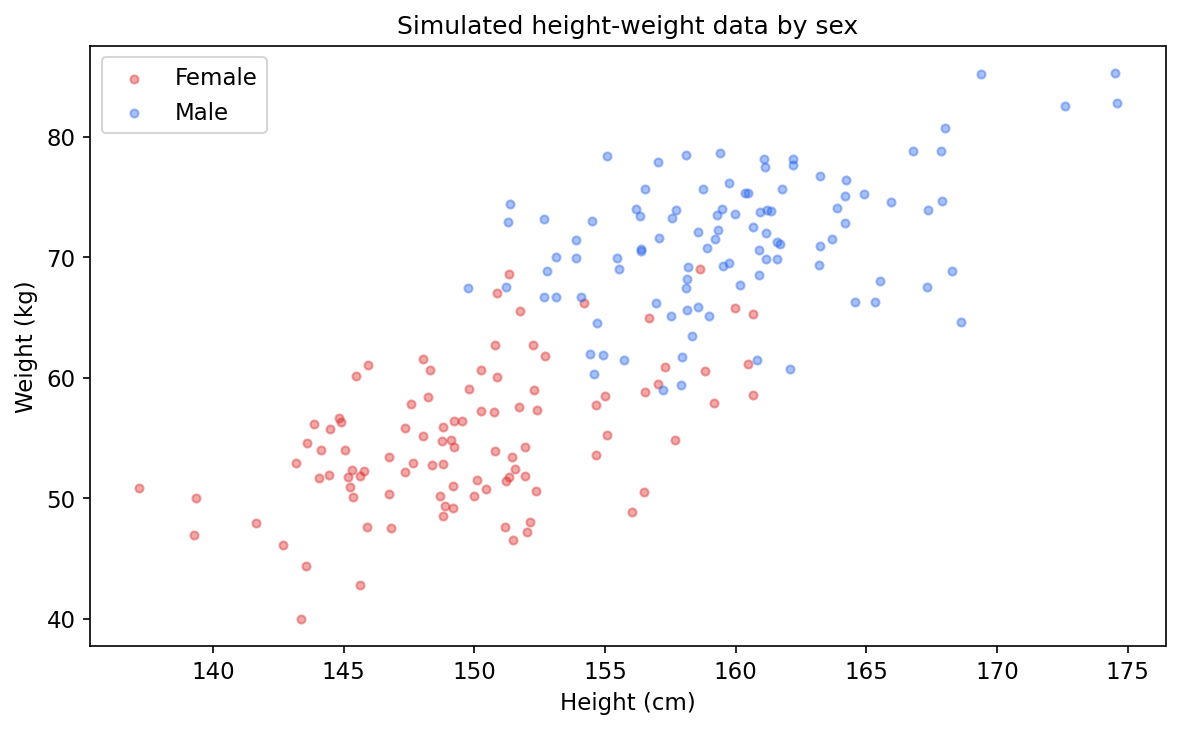

In [3]:
def sim_height_weight_sex(n: int = 200, seed: int = SEED) -> dict:
    """Simulate height-weight data with sex as categorical cause.

    S ~ Bernoulli(0.5), coded as 1 (female) or 2 (male)
    H|S=1 ~ Normal(150, 5), H|S=2 ~ Normal(160, 5)
    W = alpha[S] + beta[S] * H + Normal(0, 5)

    True: alpha = [-20, -25], beta = [0.5, 0.6]
    """
    rng = np.random.default_rng(seed)
    true_alpha = np.array([-20.0, -25.0])
    true_beta = np.array([0.5, 0.6])

    sex = rng.choice([1, 2], size=n)
    sex_idx = sex - 1
    h_mean = np.where(sex == 1, 150, 160)
    height = h_mean + rng.normal(0, 5, size=n)
    mu_w = true_alpha[sex_idx] + true_beta[sex_idx] * height
    weight = mu_w + rng.normal(0, 5, size=n)
    return {"sex": sex, "height": height, "weight": weight}

data_hw = sim_height_weight_sex()

fig, ax = plt.subplots(figsize=(8, 5))
for s, color, label in [(1, C_FEMALE, "Female"), (2, C_MALE, "Male")]:
    mask = data_hw["sex"] == s
    ax.scatter(data_hw["height"][mask], data_hw["weight"][mask],
               alpha=0.4, s=15, color=color, label=label)
ax.set_xlabel("Height (cm)"); ax.set_ylabel("Weight (kg)")
ax.set_title("Simulated height-weight data by sex")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Three Estimands from One DAG

The same DAG supports different causal questions:

1. **$P(W \mid \text{do}(H))$** — causal effect of height on weight (condition on sex)
2. **$P(W \mid \text{do}(S))$** — total effect of sex on weight (do NOT condition on height)
3. **$P(W \mid \text{do}(S), H=h)$** — direct effect of sex on weight (condition on height = mediation)

The DAG is fixed. The estimand determines which variables to include in the model.

In [4]:
# Demonstrate: total vs direct effect of sex
# Total effect: regress W on S only (don't condition on H)
# Direct effect: regress W on S and H (condition on H)

from scipy.optimize import minimize

def fit_total_effect(weights, sex):
    """W ~ Normal(alpha[S], sigma) — total effect, no height."""
    sex_idx = sex - 1
    def neg_lp(params):
        a1, a2, log_s = params
        sigma = np.exp(log_s)
        alpha = np.array([a1, a2])
        mu = alpha[sex_idx]
        return -np.sum(stats.norm.logpdf(weights, mu, sigma)) - log_s
    res = minimize(neg_lp, [60, 70, np.log(8)], method="Nelder-Mead")
    return {"alpha_female": res.x[0], "alpha_male": res.x[1], "sigma": np.exp(res.x[2])}

def fit_direct_effect(weights, heights, sex):
    """W ~ Normal(alpha[S] + beta*H, sigma) — direct effect, condition on H."""
    sex_idx = sex - 1
    def neg_lp(params):
        a1, a2, beta, log_s = params
        sigma = np.exp(log_s)
        alpha = np.array([a1, a2])
        mu = alpha[sex_idx] + beta * heights
        return -np.sum(stats.norm.logpdf(weights, mu, sigma)) - log_s
    res = minimize(neg_lp, [0, 0, 0.5, np.log(5)], method="Nelder-Mead")
    return {"alpha_female": res.x[0], "alpha_male": res.x[1],
            "beta": res.x[2], "sigma": np.exp(res.x[3])}

total = fit_total_effect(data_hw["weight"], data_hw["sex"])
direct = fit_direct_effect(data_hw["weight"], data_hw["height"], data_hw["sex"])

print("Total effect of sex (W ~ alpha[S]):")
print(f"  Female mean: {total['alpha_female']:.1f} kg")
print(f"  Male mean:   {total['alpha_male']:.1f} kg")
print(f"  Total gap:   {total['alpha_male'] - total['alpha_female']:.1f} kg")

print(f"\nDirect effect of sex (W ~ alpha[S] + beta*H):")
print(f"  Female intercept: {direct['alpha_female']:.1f}")
print(f"  Male intercept:   {direct['alpha_male']:.1f}")
print(f"  Direct gap:       {direct['alpha_male'] - direct['alpha_female']:.1f} kg (at same height)")
print(f"  beta (height):    {direct['beta']:.3f} kg/cm")
print(f"\nThe total gap is larger because it includes the indirect path S -> H -> W.")

Total effect of sex (W ~ alpha[S]):
  Female mean: 54.9 kg
  Male mean:   71.4 kg
  Total gap:   16.5 kg

Direct effect of sex (W ~ alpha[S] + beta*H):
  Female intercept: -7.1
  Male intercept:   5.1
  Direct gap:       12.3 kg (at same height)
  beta (height):    0.414 kg/cm

The total gap is larger because it includes the indirect path S -> H -> W.


## 4. Index Variables vs Dummy Variables

**Dummy coding:** one category is the reference; others are offsets. Asymmetric priors.

**Index coding (McElreath's recommendation):** each category gets its own parameter. Symmetric priors. No arbitrary reference.

$$\mu_i = \alpha_{S[i]} + \beta H_i$$

where $S[i] \in \{1, 2\}$ selects the intercept.

In [5]:
# Fit with index variable + full posterior sampling via Hessian
def quap_index_model(heights, weights, sex):
    """Fit W ~ Normal(alpha[S] + beta*H, sigma) with index variable.

    Returns posterior mode and covariance for sampling.
    """
    sex_idx = sex - 1
    def neg_lp(params):
        a1, a2, beta, log_s = params
        sigma = np.exp(log_s)
        alpha = np.array([a1, a2])
        mu = alpha[sex_idx] + beta * heights
        ll = np.sum(stats.norm.logpdf(weights, mu, sigma))
        lp = (stats.norm.logpdf(a1, 0, 10) + stats.norm.logpdf(a2, 0, 10)
              + stats.uniform.logpdf(beta, 0, 1)
              + stats.uniform.logpdf(sigma, 0, 10)
              + log_s)
        return -(ll + lp)

    x0 = np.array([0.0, 0.0, 0.5, np.log(5.0)])
    result = minimize(neg_lp, x0, method="Nelder-Mead", options={"maxiter": 10_000})

    eps = 1e-5
    hess = np.zeros((4, 4))
    for i in range(4):
        def grad_i(x, _i=i):
            return optimize.approx_fprime(x, neg_lp, eps)[_i]
        hess[i] = optimize.approx_fprime(result.x, grad_i, eps)
    cov = np.linalg.inv(hess)

    mode = result.x.copy()
    mode[3] = np.exp(mode[3])
    return {"mode": mode, "raw_mode": result.x, "cov": cov,
            "labels": ["alpha_female", "alpha_male", "beta", "sigma"]}

fit_idx = quap_index_model(data_hw["height"], data_hw["weight"], data_hw["sex"])
print("Index variable model: W ~ Normal(alpha[S] + beta*H, sigma)")
for name, val in zip(fit_idx["labels"], fit_idx["mode"]):
    print(f"  {name:>14s} = {val:.3f}")

Index variable model: W ~ Normal(alpha[S] + beta*H, sigma)
    alpha_female = -7.124
      alpha_male = 5.110
            beta = 0.414
           sigma = 5.000


## 5. Causal Contrasts as Distributions

The causal effect of sex on weight (at a given height) is $\delta = \alpha_1 - \alpha_2$. Compute from joint posterior samples to preserve correlation. The contrast is a distribution, not a number.

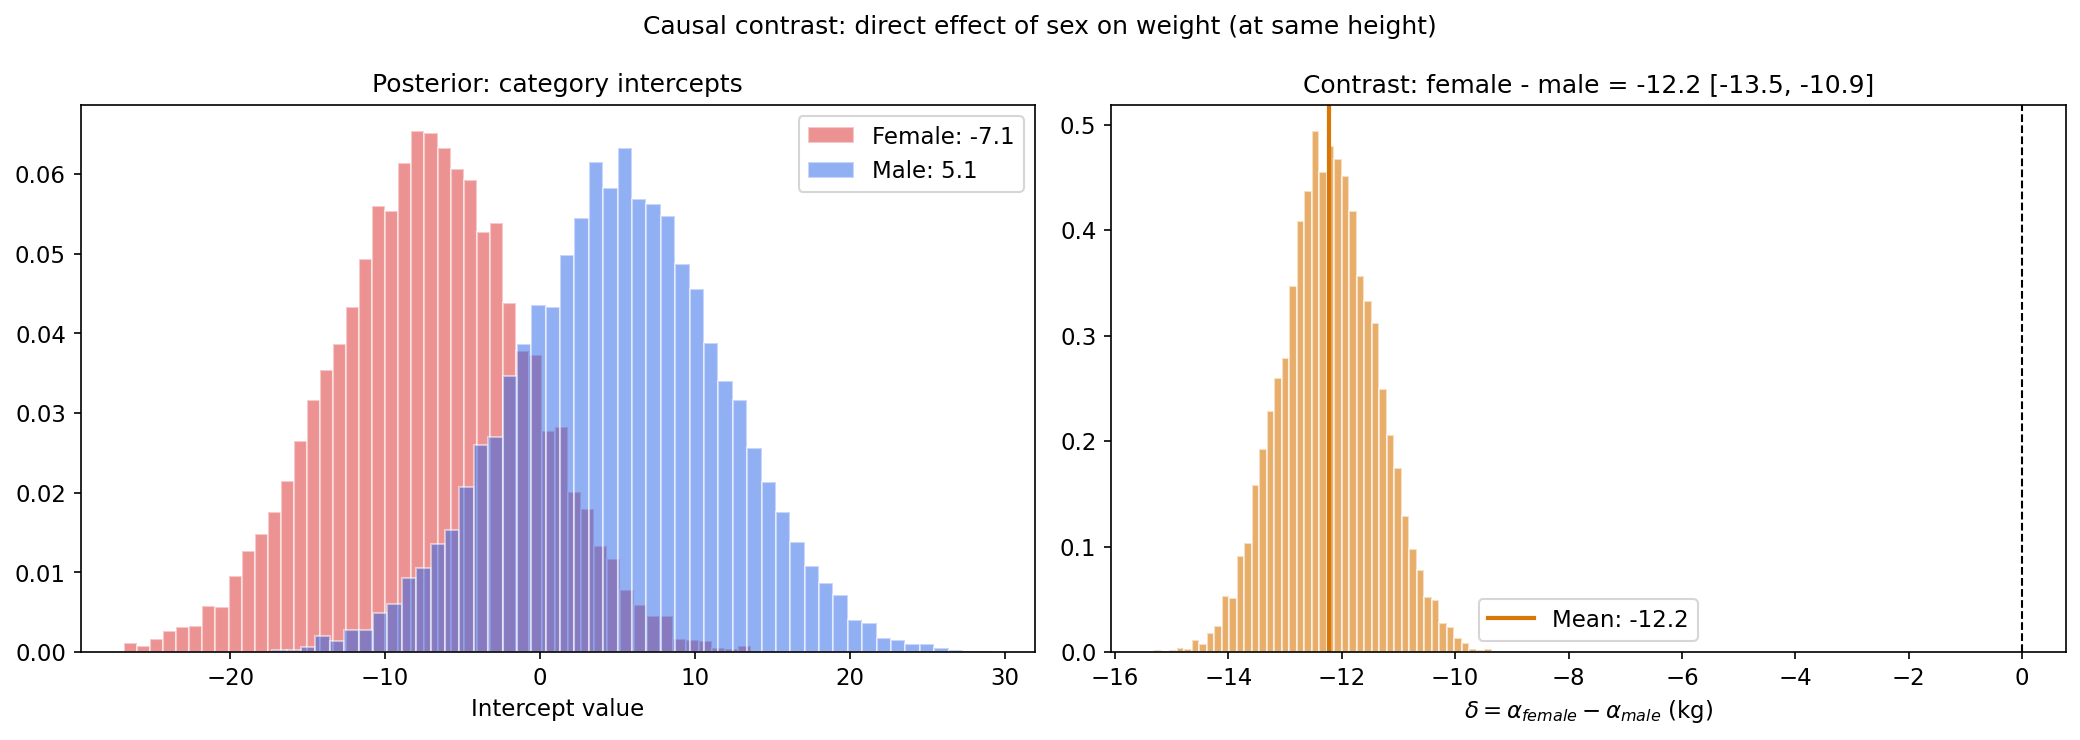

P(female lighter than male at same height) = 1.000


In [6]:
# Sample from approximate posterior and compute contrast
rng_c = np.random.default_rng(SEED)
samp_idx = rng_c.multivariate_normal(fit_idx["raw_mode"], fit_idx["cov"], size=N_SAMPLES)
a1_samp = samp_idx[:, 0]  # alpha_female
a2_samp = samp_idx[:, 1]  # alpha_male
beta_samp = samp_idx[:, 2]
sigma_samp = np.exp(samp_idx[:, 3])

delta = a1_samp - a2_samp  # female - male

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: marginal posteriors for alpha_1, alpha_2
axes[0].hist(a1_samp, bins=50, density=True, alpha=0.5, color=C_FEMALE, edgecolor="white",
             label=f"Female: {a1_samp.mean():.1f}")
axes[0].hist(a2_samp, bins=50, density=True, alpha=0.5, color=C_MALE, edgecolor="white",
             label=f"Male: {a2_samp.mean():.1f}")
axes[0].set_title("Posterior: category intercepts")
axes[0].set_xlabel("Intercept value")
axes[0].legend()

# Right: contrast distribution
ci_lo, ci_hi = np.percentile(delta, 5.5), np.percentile(delta, 94.5)
axes[1].hist(delta, bins=50, density=True, alpha=0.6, color=C_ACCENT, edgecolor="white")
axes[1].axvline(0, color="black", linewidth=1, linestyle="--")
axes[1].axvline(delta.mean(), color=C_ACCENT, linewidth=2, label=f"Mean: {delta.mean():.1f}")
axes[1].set_title(f"Contrast: female - male = {delta.mean():.1f} [{ci_lo:.1f}, {ci_hi:.1f}]")
axes[1].set_xlabel(r"$\delta = \alpha_{female} - \alpha_{male}$ (kg)")
axes[1].legend()

plt.suptitle("Causal contrast: direct effect of sex on weight (at same height)", fontsize=12)
plt.tight_layout()
plt.show()

print(f"P(female lighter than male at same height) = {(delta < 0).mean():.3f}")

---

# Part 2: Applied Exercises with Slovenian Data

Index variables, causal contrasts, and the total-vs-direct distinction applied to real datasets. All real estate exercises scoped to 2022+.

In [7]:
# Load datasets
re = pd.read_csv(DATA_DIR / "sr2026_real_estate.csv", parse_dates=["date"])
forensic = pd.read_csv(DATA_DIR / "sr2026_forensic_audio.csv")
mun = pd.read_csv(DATA_DIR / "sr2026_municipality_panel.csv")

YEAR_MIN = 2022
re_recent = re[
    (re["year"] >= YEAR_MIN)
    & re["price_per_m2"].notna()
    & re["area_m2"].notna()
    & (re["area_m2"] > 10) & (re["area_m2"] < 300)
    & (re["price_eur"] > 5_000) & (re["price_eur"] < 1_000_000)
].copy()

print(f"Real estate ({YEAR_MIN}+): {len(re_recent):,} transactions")
print(f"Property types: {re_recent['property_type'].nunique()}")
print(re_recent["property_type"].value_counts().head(6).to_string())

Real estate (2022+): 27,357 transactions
Property types: 12
property_type
apartment           15525
detached_house       6014
garage               1587
agricultural         1488
parking               723
other_commercial      446


## Exercise 1: Property Type as Index Variable

**DAG:** $\text{Type} \rightarrow \text{Price}$, $\text{Area} \rightarrow \text{Price}$, $\text{Type} \rightarrow \text{Area}$

**Estimand:** Direct effect of property type on price per m2, controlling for area.

**Model:** $\text{Price}_i \sim \text{Normal}(\alpha_{T[i]} + \beta \cdot \text{Area}_i, \sigma)$

Each property type gets its own intercept via index coding. Symmetric priors on all intercepts.

In [8]:
# Select top 3 property types for clean comparison
top_types = re_recent["property_type"].value_counts().head(3).index.tolist()
re_types = re_recent[re_recent["property_type"].isin(top_types)].copy()

# Create integer index
type_map = {t: i for i, t in enumerate(top_types)}
re_types["type_idx"] = re_types["property_type"].map(type_map)

print(f"Selected types: {top_types}")
for t in top_types:
    sub = re_types[re_types["property_type"] == t]
    print(f"  {t:20s}: n={len(sub):,}, median price/m2={sub['price_per_m2'].median():,.0f}")

Selected types: ['apartment', 'detached_house', 'garage']
  apartment           : n=15,525, median price/m2=2,137
  detached_house      : n=6,014, median price/m2=974
  garage              : n=1,587, median price/m2=923


In [9]:
# Fit index variable model: price_eur ~ Normal(alpha[type] + beta * area, sigma)
areas = re_types["area_m2"].values
prices = re_types["price_eur"].values
type_idx = re_types["type_idx"].values
n_types = len(top_types)

def quap_property_type(areas, prices, type_idx, n_types):
    """Fit price ~ alpha[type] + beta*area."""
    def neg_lp(params):
        alphas = params[:n_types]
        beta = params[n_types]
        log_s = params[n_types + 1]
        sigma = np.exp(log_s)
        mu = alphas[type_idx] + beta * areas
        ll = np.sum(stats.norm.logpdf(prices, mu, sigma))
        lp = sum(stats.norm.logpdf(a, 0, 100_000) for a in alphas)
        lp += stats.norm.logpdf(beta, 3000, 1500) + log_s
        if sigma <= 0: return 1e12
        return -(ll + lp)

    x0 = np.zeros(n_types + 2)
    x0[:n_types] = 10_000
    x0[n_types] = 3000
    x0[n_types + 1] = np.log(40_000)
    result = minimize(neg_lp, x0, method="Nelder-Mead", options={"maxiter": 20_000})

    eps = 1e-4
    n_params = n_types + 2
    hess = np.zeros((n_params, n_params))
    for i in range(n_params):
        def grad_i(x, _i=i):
            return optimize.approx_fprime(x, neg_lp, eps)[_i]
        hess[i] = optimize.approx_fprime(result.x, grad_i, eps)
    cov = np.linalg.inv(hess)

    mode = result.x.copy()
    mode[-1] = np.exp(mode[-1])
    return {"mode": mode, "raw_mode": result.x, "cov": cov}

fit_pt = quap_property_type(areas, prices, type_idx, n_types)

print("Property type index model: price ~ alpha[type] + beta * area")
for i, t in enumerate(top_types):
    print(f"  alpha[{t}] = {fit_pt['mode'][i]:>10,.0f} EUR")
print(f"  beta (EUR/m2)  = {fit_pt['mode'][n_types]:>10,.0f}")
print(f"  sigma          = {fit_pt['mode'][n_types+1]:>10,.0f}")

Property type index model: price ~ alpha[type] + beta * area
  alpha[apartment] =     77,906 EUR
  alpha[detached_house] =     21,687 EUR
  alpha[garage] =       -863 EUR
  beta (EUR/m2)  =        991
  sigma          =     86,738


/tmp/ipykernel_2008648/3080111021.py:3: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samp_pt = rng_pt.multivariate_normal(fit_pt["raw_mode"], fit_pt["cov"], size=N_SAMPLES)


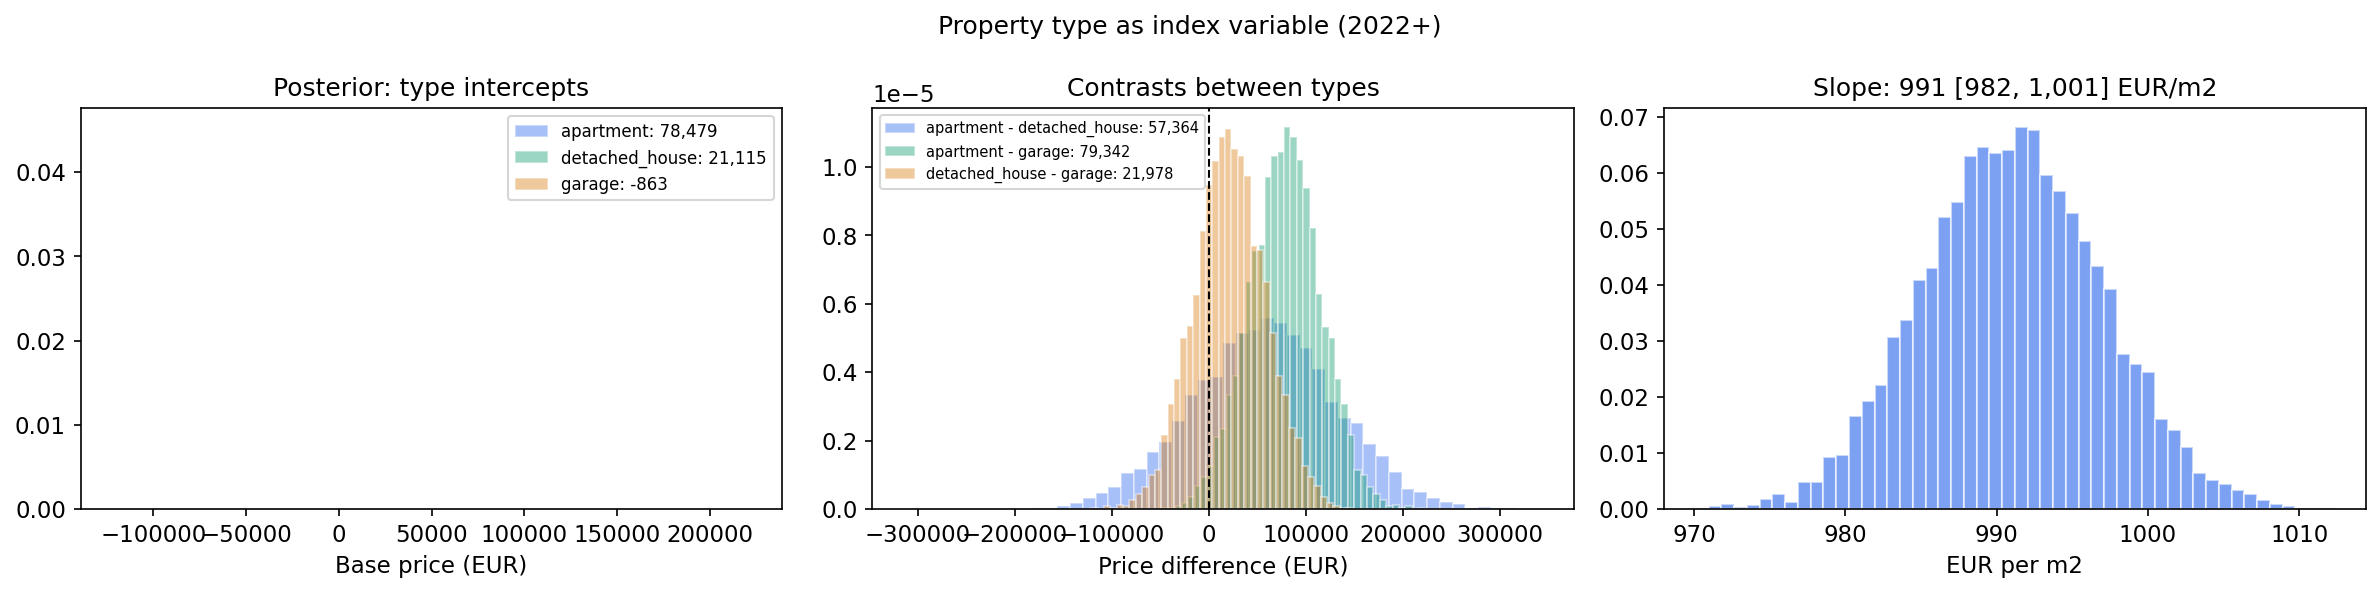

In [10]:
# Causal contrasts between property types
rng_pt = np.random.default_rng(SEED)
samp_pt = rng_pt.multivariate_normal(fit_pt["raw_mode"], fit_pt["cov"], size=N_SAMPLES)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Marginal posteriors for intercepts
for i, (t, color) in enumerate(zip(top_types, [C_POSTERIOR, C_DATA, C_ACCENT])):
    alpha_i = samp_pt[:, i]
    axes[0].hist(alpha_i, bins=50, density=True, alpha=0.4, color=color,
                 edgecolor="white", label=f"{t}: {alpha_i.mean():,.0f}")
axes[0].set_title("Posterior: type intercepts")
axes[0].set_xlabel("Base price (EUR)")
axes[0].legend(fontsize=8)

# Pairwise contrasts
contrasts = {}
pair_idx = 0
for i in range(n_types):
    for j in range(i + 1, n_types):
        delta = samp_pt[:, i] - samp_pt[:, j]
        ci = np.percentile(delta, [5.5, 94.5])
        name = f"{top_types[i]} - {top_types[j]}"
        contrasts[name] = delta
        pair_idx += 1

ax = axes[1]
for k, (name, delta) in enumerate(contrasts.items()):
    ci = np.percentile(delta, [5.5, 94.5])
    color = [C_POSTERIOR, C_DATA, C_ACCENT][k % 3]
    ax.hist(delta, bins=50, density=True, alpha=0.4, color=color, edgecolor="white",
            label=f"{name}: {delta.mean():,.0f}")
ax.axvline(0, color="black", linewidth=1, linestyle="--")
ax.set_title("Contrasts between types")
ax.set_xlabel("Price difference (EUR)")
ax.legend(fontsize=7)

# Beta (slope) posterior
beta_pt = samp_pt[:, n_types]
ci_b = np.percentile(beta_pt, [5.5, 94.5])
axes[2].hist(beta_pt, bins=50, density=True, alpha=0.6, color=C_POSTERIOR, edgecolor="white")
axes[2].set_title(f"Slope: {beta_pt.mean():,.0f} [{ci_b[0]:,.0f}, {ci_b[1]:,.0f}] EUR/m2")
axes[2].set_xlabel("EUR per m2")

plt.suptitle(f"Property type as index variable ({YEAR_MIN}+)", fontsize=12)
plt.tight_layout()
plt.show()

## Exercise 2: Forensic Audio — Device Type Contrasts

**DAG:** $\text{Device} \rightarrow \text{ENF\_SNR}$, $\text{Device} \rightarrow \text{Bandwidth}$, $\text{Category} \rightarrow \text{ENF\_SNR}$

**Estimand:** Direct effect of recording device on ENF signal-to-noise ratio, controlling for bandwidth. The device effect must be separated from authenticity effects before computing likelihood ratios.

**Model:** $\text{ENF}_{50\text{Hz},i} \sim \text{Normal}(\alpha_{D[i]} + \beta \cdot \text{BW}_i, \sigma)$

In [11]:
# Device contrasts for ENF SNR
dev_counts = forensic["device"].value_counts()
top_devs = dev_counts[dev_counts >= 10].index.tolist()
for_dev = forensic[forensic["device"].isin(top_devs) & forensic["enf_snr_50hz"].notna()
                    & forensic["bandwidth_hz"].notna()].copy()
dev_map = {d: i for i, d in enumerate(top_devs)}
for_dev["dev_idx"] = for_dev["device"].map(dev_map)
n_devs = len(top_devs)

print(f"Devices with n>=10: {top_devs}")
for d in top_devs:
    sub = for_dev[for_dev["device"] == d]
    print(f"  {d:25s}: n={len(sub)}, median ENF SNR = {sub['enf_snr_50hz'].median():.1f} dB")

Devices with n>=10: ['laptop_mic', 'usb_mic', 'voip', 'smartphone_android', 'landline', 'smartphone_ios']
  laptop_mic               : n=58, median ENF SNR = 1.4 dB
  usb_mic                  : n=51, median ENF SNR = 1.7 dB
  voip                     : n=45, median ENF SNR = 1.6 dB
  smartphone_android       : n=14, median ENF SNR = 8.3 dB
  landline                 : n=14, median ENF SNR = 7.7 dB
  smartphone_ios           : n=11, median ENF SNR = 1.0 dB


In [12]:
# Fit: ENF_SNR ~ alpha[device] + beta * bandwidth
enf = for_dev["enf_snr_50hz"].values
bw = for_dev["bandwidth_hz"].values
didx = for_dev["dev_idx"].values

def quap_device_enf(enf, bw, didx, n_devs):
    def neg_lp(params):
        alphas = params[:n_devs]
        beta = params[n_devs]
        log_s = params[n_devs + 1]
        sigma = np.exp(log_s)
        mu = alphas[didx] + beta * bw
        ll = np.sum(stats.norm.logpdf(enf, mu, sigma))
        lp = sum(stats.norm.logpdf(a, 0, 20) for a in alphas)
        lp += stats.norm.logpdf(beta, 0, 0.01) + log_s
        if sigma <= 0: return 1e12
        return -(ll + lp)

    x0 = np.zeros(n_devs + 2)
    x0[:n_devs] = enf.mean()
    x0[n_devs] = 0.0
    x0[n_devs + 1] = np.log(enf.std())
    result = minimize(neg_lp, x0, method="Nelder-Mead", options={"maxiter": 20_000})

    eps = 1e-5
    np_ = n_devs + 2
    hess = np.zeros((np_, np_))
    for i in range(np_):
        def grad_i(x, _i=i):
            return optimize.approx_fprime(x, neg_lp, eps)[_i]
        hess[i] = optimize.approx_fprime(result.x, grad_i, eps)

    try:
        cov = np.linalg.inv(hess)
    except np.linalg.LinAlgError:
        cov = np.eye(np_) * 0.1  # fallback
    return {"mode": result.x.copy(), "cov": cov, "raw_mode": result.x}

fit_dev = quap_device_enf(enf, bw, didx, n_devs)

print("Device index model: ENF_SNR ~ alpha[device] + beta * bandwidth")
for i, d in enumerate(top_devs):
    print(f"  alpha[{d:20s}] = {fit_dev['mode'][i]:.2f} dB")
print(f"  beta (per Hz bandwidth) = {fit_dev['mode'][n_devs]:.6f}")
print(f"  sigma                   = {np.exp(fit_dev['mode'][n_devs+1]):.2f} dB")

Device index model: ENF_SNR ~ alpha[device] + beta * bandwidth
  alpha[laptop_mic          ] = 1.74 dB
  alpha[usb_mic             ] = 1.06 dB
  alpha[voip                ] = 3.20 dB
  alpha[smartphone_android  ] = 2.74 dB
  alpha[landline            ] = 6.58 dB
  alpha[smartphone_ios      ] = -5.50 dB
  beta (per Hz bandwidth) = 0.000448
  sigma                   = 7.45 dB


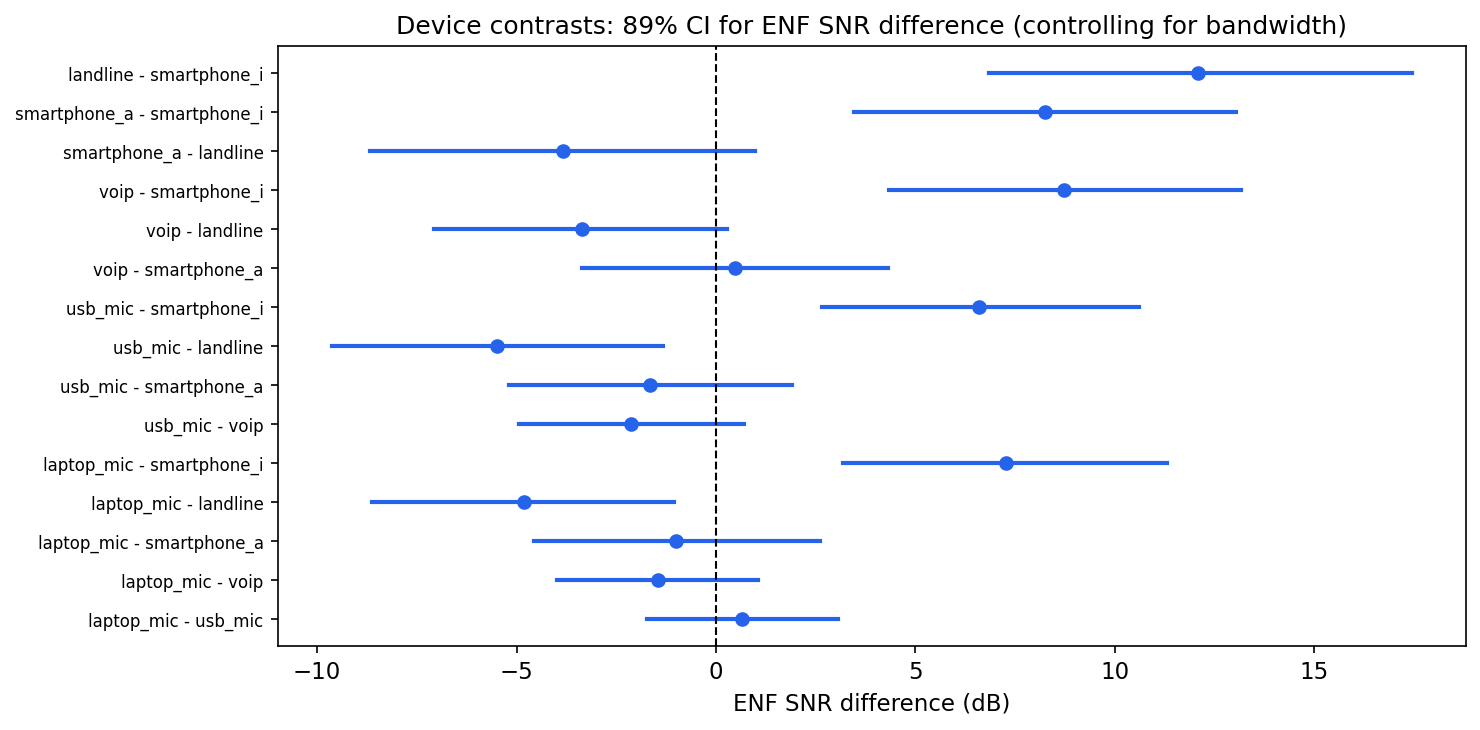

Contrasts overlapping zero: device effect is uncertain at this sample size.
Contrasts excluding zero: device correction needed before LR computation.


In [13]:
# Device contrasts
rng_dev = np.random.default_rng(SEED)
samp_dev = rng_dev.multivariate_normal(fit_dev["raw_mode"], fit_dev["cov"], size=N_SAMPLES)

fig, ax = plt.subplots(figsize=(10, 5))

# Pairwise contrasts between devices
colors_dev = plt.cm.tab10(np.linspace(0, 1, n_devs * (n_devs - 1) // 2))
k = 0
contrast_summaries = []
for i in range(n_devs):
    for j in range(i + 1, n_devs):
        d = samp_dev[:, i] - samp_dev[:, j]
        ci = np.percentile(d, [5.5, 94.5])
        name = f"{top_devs[i][:12]} - {top_devs[j][:12]}"
        contrast_summaries.append((name, d.mean(), ci[0], ci[1]))
        k += 1

# Forest plot
y_pos = range(len(contrast_summaries))
for y, (name, mean, lo, hi) in zip(y_pos, contrast_summaries):
    ax.plot([lo, hi], [y, y], color=C_POSTERIOR, linewidth=2)
    ax.plot(mean, y, "o", color=C_POSTERIOR, markersize=6)

ax.axvline(0, color="black", linewidth=1, linestyle="--")
ax.set_yticks(list(y_pos))
ax.set_yticklabels([c[0] for c in contrast_summaries], fontsize=8)
ax.set_xlabel("ENF SNR difference (dB)")
ax.set_title("Device contrasts: 89% CI for ENF SNR difference (controlling for bandwidth)")
plt.tight_layout()
plt.show()

print("Contrasts overlapping zero: device effect is uncertain at this sample size.")
print("Contrasts excluding zero: device correction needed before LR computation.")

## Exercise 3: Total vs Direct Effect of Municipality on Price

**Estimand 1 (total):** How does municipality affect price? (Don't control for area — area itself varies by municipality.)

**Estimand 2 (direct):** How does municipality affect price, holding area constant? (Isolates the location premium.)

The difference between total and direct: in desirable municipalities, apartments tend to be larger (selection effect). The total effect includes this; the direct effect strips it out.

In [14]:
# Compare two municipalities: Ljubljana vs next largest
mun_pair = re_recent[
    re_recent["property_type"] == "apartment"
].copy()
top2_mun = mun_pair["municipality"].value_counts().head(2).index.tolist()
mun_pair = mun_pair[mun_pair["municipality"].isin(top2_mun)].copy()
mun_pair["mun_idx"] = (mun_pair["municipality"] == top2_mun[1]).astype(int)

print(f"Comparing: {top2_mun[0]} vs {top2_mun[1]}")
for m in top2_mun:
    sub = mun_pair[mun_pair["municipality"] == m]
    print(f"  {m}: n={len(sub):,}, median area={sub['area_m2'].median():.0f} m2, "
          f"median price={sub['price_eur'].median():,.0f} EUR")

Comparing: LJUBLJANA vs MARIBOR
  LJUBLJANA: n=3,629, median area=58 m2, median price=200,000 EUR
  MARIBOR: n=1,974, median area=57 m2, median price=100,000 EUR


In [15]:
# Total effect: price ~ alpha[mun] (no area control)
midx = mun_pair["mun_idx"].values
pr = mun_pair["price_eur"].values
ar = mun_pair["area_m2"].values

def fit_mun_total(prices, midx):
    def neg_lp(params):
        a0, a1, log_s = params
        sigma = np.exp(log_s)
        mu = np.where(midx == 0, a0, a1)
        return -np.sum(stats.norm.logpdf(prices, mu, sigma)) - log_s
    res = minimize(neg_lp, [150_000, 100_000, np.log(50_000)], method="Nelder-Mead")
    return res.x

def fit_mun_direct(prices, areas, midx):
    def neg_lp(params):
        a0, a1, beta, log_s = params
        sigma = np.exp(log_s)
        alpha = np.where(midx == 0, a0, a1)
        mu = alpha + beta * areas
        return -np.sum(stats.norm.logpdf(prices, mu, sigma)) - log_s
    res = minimize(neg_lp, [10_000, 10_000, 3000, np.log(40_000)], method="Nelder-Mead",
                   options={"maxiter": 20_000})
    return res.x

total_params = fit_mun_total(pr, midx)
direct_params = fit_mun_direct(pr, ar, midx)

total_gap = total_params[0] - total_params[1]
direct_gap = direct_params[0] - direct_params[1]

print(f"Total effect (price ~ mun):")
print(f"  {top2_mun[0]}: {total_params[0]:,.0f} EUR")
print(f"  {top2_mun[1]}: {total_params[1]:,.0f} EUR")
print(f"  Total gap: {total_gap:,.0f} EUR")

print(f"\nDirect effect (price ~ mun + area):")
print(f"  {top2_mun[0]} intercept: {direct_params[0]:,.0f} EUR")
print(f"  {top2_mun[1]} intercept: {direct_params[1]:,.0f} EUR")
print(f"  Direct gap: {direct_gap:,.0f} EUR (at same area)")
print(f"  beta: {direct_params[2]:,.0f} EUR/m2")

print(f"\nDifference: {abs(total_gap) - abs(direct_gap):,.0f} EUR is mediated through area differences.")

Total effect (price ~ mun):
  LJUBLJANA: 212,712 EUR
  MARIBOR: 102,061 EUR
  Total gap: 110,651 EUR

Direct effect (price ~ mun + area):
  LJUBLJANA intercept: 80,902 EUR
  MARIBOR intercept: -20,537 EUR
  Direct gap: 101,438 EUR (at same area)
  beta: 2,078 EUR/m2

Difference: 9,212 EUR is mediated through area differences.


## Exercise 4: Forensic Audio — Authenticity Category Contrasts

**Estimand:** Direct effect of manipulation category on ENF SNR, controlling for duration.

**Model:** $\text{ENF}_{50\text{Hz},i} \sim \text{Normal}(\alpha_{C[i]} + \beta \cdot \text{Duration}_i, \sigma)$

The contrast between authentic and each manipulation type quantifies the forensic signal. Larger contrasts = easier to detect.

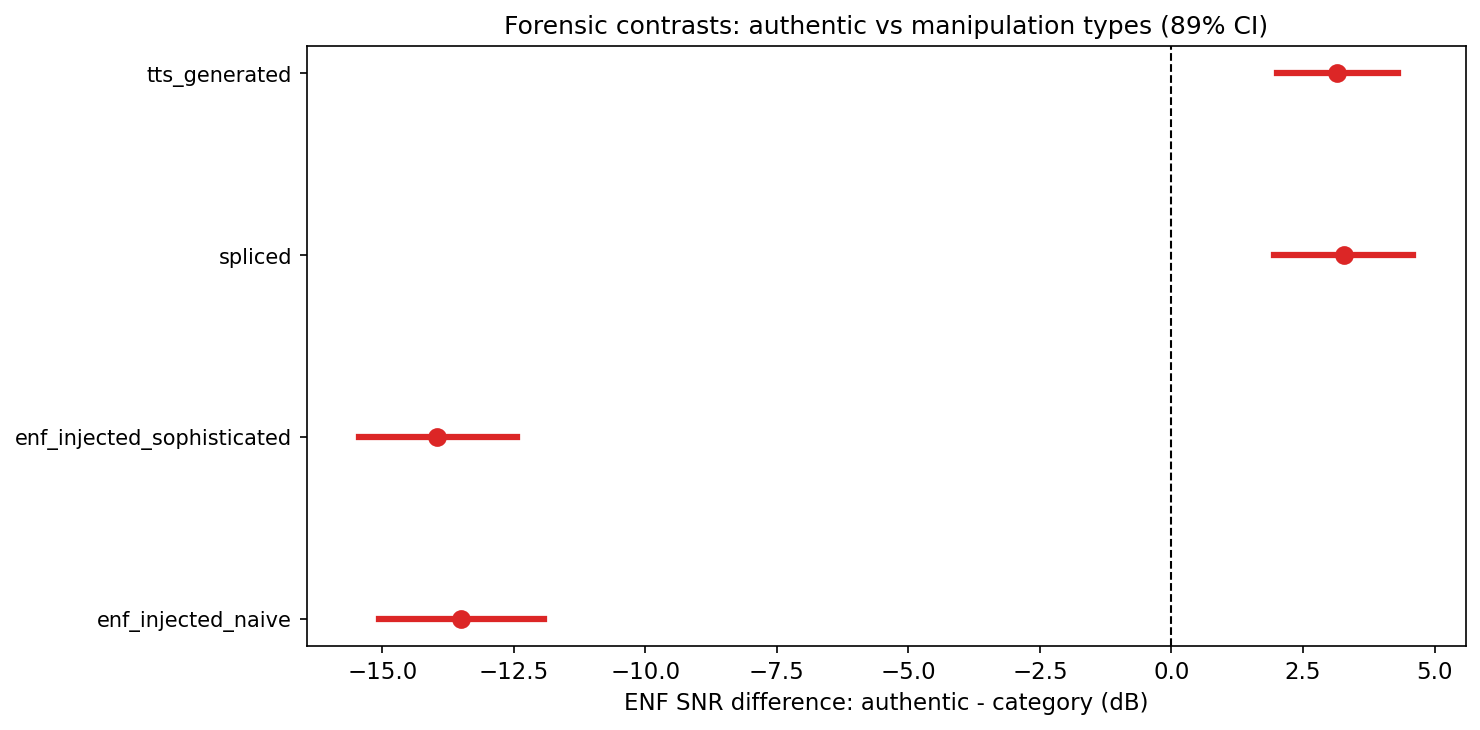

Red: contrast excludes zero — manipulation detectably different from authentic.
Gray: contrast includes zero — cannot reliably distinguish from authentic.


In [16]:
# Category index model for forensic audio
cats = forensic["category"].unique()
cat_map = {c: i for i, c in enumerate(sorted(cats))}
forensic_clean = forensic[forensic["enf_snr_50hz"].notna() & forensic["duration_s"].notna()].copy()
forensic_clean["cat_idx"] = forensic_clean["category"].map(cat_map)
n_cats = len(cats)
sorted_cats = sorted(cats)

enf_vals = forensic_clean["enf_snr_50hz"].values
dur_vals = forensic_clean["duration_s"].values
cidx = forensic_clean["cat_idx"].values

def quap_category_enf(enf, dur, cidx, n_cats):
    def neg_lp(params):
        alphas = params[:n_cats]
        beta = params[n_cats]
        log_s = params[n_cats + 1]
        sigma = np.exp(log_s)
        mu = alphas[cidx] + beta * dur
        ll = np.sum(stats.norm.logpdf(enf, mu, sigma))
        lp = sum(stats.norm.logpdf(a, 0, 20) for a in alphas) + log_s
        if sigma <= 0: return 1e12
        return -(ll + lp)

    x0 = np.zeros(n_cats + 2)
    x0[:n_cats] = enf.mean()
    x0[n_cats + 1] = np.log(enf.std())
    result = minimize(neg_lp, x0, method="Nelder-Mead", options={"maxiter": 20_000})
    eps = 1e-5
    np_ = n_cats + 2
    hess = np.zeros((np_, np_))
    for i in range(np_):
        def grad_i(x, _i=i):
            return optimize.approx_fprime(x, neg_lp, eps)[_i]
        hess[i] = optimize.approx_fprime(result.x, grad_i, eps)
    try:
        cov = np.linalg.inv(hess)
    except np.linalg.LinAlgError:
        cov = np.eye(np_) * 0.1
    return {"mode": result.x.copy(), "cov": cov}

fit_cat = quap_category_enf(enf_vals, dur_vals, cidx, n_cats)

# Sample and compute contrasts vs authentic
auth_idx = cat_map.get("authentic", 0)
rng_cat = np.random.default_rng(SEED)
samp_cat = rng_cat.multivariate_normal(fit_cat["mode"], fit_cat["cov"], size=N_SAMPLES)

fig, ax = plt.subplots(figsize=(10, 5))
contrast_data = []
for i, cat in enumerate(sorted_cats):
    if cat == "authentic":
        continue
    delta = samp_cat[:, auth_idx] - samp_cat[:, i]
    ci = np.percentile(delta, [5.5, 94.5])
    contrast_data.append((cat, delta.mean(), ci[0], ci[1]))

y_pos = range(len(contrast_data))
for y, (name, mean, lo, hi) in zip(y_pos, contrast_data):
    contains_zero = lo <= 0 <= hi
    color = C_PRIOR if contains_zero else C_LIKELIHOOD
    ax.plot([lo, hi], [y, y], color=color, linewidth=3)
    ax.plot(mean, y, "o", color=color, markersize=8)

ax.axvline(0, color="black", linewidth=1, linestyle="--")
ax.set_yticks(list(y_pos))
ax.set_yticklabels([c[0] for c in contrast_data], fontsize=10)
ax.set_xlabel("ENF SNR difference: authentic - category (dB)")
ax.set_title("Forensic contrasts: authentic vs manipulation types (89% CI)")
plt.tight_layout()
plt.show()

print("Red: contrast excludes zero — manipulation detectably different from authentic.")
print("Gray: contrast includes zero — cannot reliably distinguish from authentic.")

---

# Key Takeaways

1. **Epistemic vs aleatoric uncertainty.** The narrow band (regression line uncertainty) shrinks with data. The wide band (observation scatter) does not. OTP Bank needs the narrow band for benchmarks; buyers need the wide band for transaction risk.

2. **Three estimands from one DAG.** Total effect of location on price (don't control for area), direct effect (control for area), mediation (how much goes through area). The DAG is fixed; the estimand determines the model.

3. **Index variables over dummy variables.** Each property type, device, or category gets its own parameter. Symmetric priors, no arbitrary reference, scales cleanly.

4. **Causal contrasts are distributions.** The apartment-house price difference is not a number but a posterior distribution. Compute from joint samples. Summarize last.

5. **Forensic device contrasts inform LR calibration.** If two devices shift ENF SNR by 3 dB, that shift must be corrected before computing a speaker likelihood ratio. The posterior on the contrast quantifies the correction uncertainty.

6. **Total vs direct gap quantifies mediation.** The total Ljubljana premium includes the fact that Ljubljana apartments tend to be different. The direct gap isolates the pure location effect. The difference is the mediated component.

**Next:** [[Lecture A05]] introduces estimands formally, distinguishing total, direct, and indirect effects with the do-calculus.